# Credit Risk Prediction Model using Machine Learning Project

#### Credit Risk Analysis

Lending is a core function of financial institutions, but it inherently involves the risk of borrower default. Inadequate credit risk assessment can lead to financial losses, reduced profitability, and deterioration of overall portfolio quality.

This project aims to identify high-risk customers and predict the likelihood of loan default using historical data. By leveraging data analysis and predictive modeling techniques, the goal is to support more informed lending decisions and improve risk management strategies.
areful handling.

# 1. Importing the Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 2. Loading the dataset

In [3]:
df = pd.read_csv("C:/Users/aritr/Downloads/credit_risk_dataset.csv/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# 3. Data Preprocessing

In [4]:
df.shape

(32581, 12)

df.describe(include='all')

**Handle missing values**

In [5]:
# Cheking missing values in columns
df_missing_values = df.isnull().sum()
df_missing_values

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [6]:
emp_startage=(df['person_age']-df['person_emp_length']).mode()[0]
emp_startage

16.0

In [7]:
df['person_emp_length']=df['person_emp_length'].fillna(df['person_age']-emp_startage)

In [8]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [9]:
df['loan_int_rate']=df['loan_int_rate'].fillna(df['loan_int_rate'].mode()[0])

In [10]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

**Data Didtribution Analysis**

In [11]:
loanstatus = df['loan_status'].value_counts()
loanstatus

loan_status
0    25473
1     7108
Name: count, dtype: int64

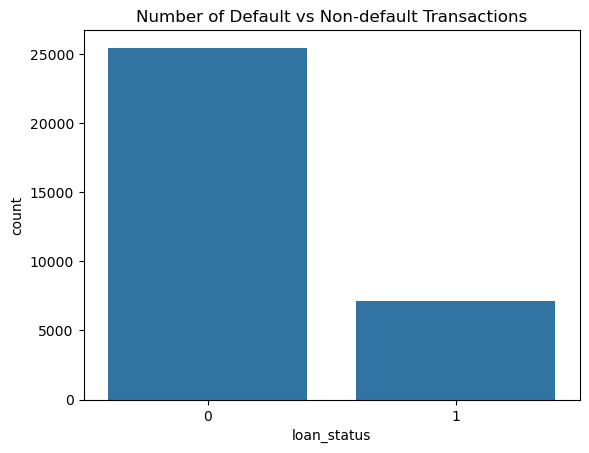

In [12]:
sns.countplot(x='loan_status', data=df)
plt.title('Number of Default vs Non-default Transactions')
plt.show()

In [13]:
df.describe(include='all')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581,32581.00000,32581,32581,32581.000000,32581.000000,32581.000000,32581.000000,32581,32581.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,16446,NaN,6453,10777,NaN,NaN,NaN,NaN,26836,NaN
mean,27.734600,6.607485e+04,NaN,4.96811,NaN,NaN,9589.371106,10.676798,0.218164,0.170203,NaN,5.804211
std,6.348078,6.198312e+04,NaN,4.33215,NaN,NaN,6322.086646,3.249134,0.413006,0.106782,NaN,4.055001
min,20.000000,4.000000e+03,NaN,0.00000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,23.000000,3.850000e+04,NaN,2.00000,NaN,NaN,5000.000000,7.510000,0.000000,0.090000,NaN,3.000000
50%,26.000000,5.500000e+04,NaN,4.00000,NaN,NaN,8000.000000,10.620000,0.000000,0.150000,NaN,4.000000
75%,30.000000,7.920000e+04,NaN,7.00000,NaN,NaN,12200.000000,13.110000,0.000000,0.230000,NaN,8.000000


In [14]:
df.person_age.value_counts().sort_index()

person_age
20       15
21     1229
22     3633
23     3889
24     3549
25     3037
26     2477
27     2138
28     1854
29     1687
30     1316
31     1142
32      964
33      856
34      709
35      620
36      548
37      478
38      373
39      302
40      271
41      241
42      188
43      164
44      141
45      108
46       94
47       94
48       75
49       49
50       52
51       39
52       36
53       30
54       24
55       20
56       15
57       15
58       19
59        5
60       15
61        9
62        7
63        3
64        7
65        9
66        9
67        1
69        5
70        7
73        3
76        1
78        1
80        1
84        1
94        1
123       2
144       3
Name: count, dtype: int64

In [15]:
df[df['person_age']>70].loan_status.value_counts()

loan_status
0    13
Name: count, dtype: int64

In [16]:
df=df[df['person_age']<=70]
df.shape

(32568, 12)

In [17]:
df.person_emp_length.value_counts().sort_index()

person_emp_length
0.0      4103
1.0      2914
2.0      3847
3.0      3456
4.0      2872
5.0      2997
6.0      2780
7.0      2308
8.0      1781
9.0      1452
10.0      753
11.0      783
12.0      623
13.0      467
14.0      385
15.0      270
16.0      185
17.0      153
18.0      122
19.0       78
20.0       56
21.0       47
22.0       30
23.0       19
24.0       20
25.0       15
26.0        9
27.0       12
28.0       10
29.0        1
30.0        2
31.0        7
32.0        1
33.0        1
34.0        2
35.0        1
37.0        1
38.0        1
40.0        1
54.0        1
123.0       2
Name: count, dtype: int64

In [18]:
df=df[df['person_emp_length']!=123]
df.shape

(32566, 12)

In [19]:
df.reset_index(drop=True,inplace=True)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


# 4. Categorical feature treatement

In [20]:
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent', 'cb_person_default_on_file','loan_grade'])
df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,...,loan_intent_VENTURE,cb_person_default_on_file_N,cb_person_default_on_file_Y,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,21,9600,5.0,1000,11.14,0,0.10,2,False,False,...,False,True,False,False,True,False,False,False,False,False
1,25,9600,1.0,5500,12.87,1,0.57,3,True,False,...,False,True,False,False,False,True,False,False,False,False
2,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,False,True,False,False,False,True,False,False,False,False
3,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,False,False,True,False,False,True,False,False,False,False
4,21,9900,2.0,2500,7.14,1,0.25,2,False,False,...,True,True,False,True,False,False,False,False,False,False


In [21]:
df.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'cb_person_default_on_file_N', 'cb_person_default_on_file_Y',
       'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D',
       'loan_grade_E', 'loan_grade_F', 'loan_grade_G'],
      dtype='object')

In [22]:
df[['person_home_ownership_MORTGAGE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'cb_person_default_on_file_N', 'cb_person_default_on_file_Y',
       'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D',
       'loan_grade_E', 'loan_grade_F', 'loan_grade_G']] = df[['person_home_ownership_MORTGAGE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'cb_person_default_on_file_N', 'cb_person_default_on_file_Y',
       'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D',
       'loan_grade_E', 'loan_grade_F', 'loan_grade_G']].applymap(lambda x: 1 if x==True else 0)
df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,...,loan_intent_VENTURE,cb_person_default_on_file_N,cb_person_default_on_file_Y,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,21,9600,5.0,1000,11.14,0,0.10,2,0,0,...,0,1,0,0,1,0,0,0,0,0
1,25,9600,1.0,5500,12.87,1,0.57,3,1,0,...,0,1,0,0,0,1,0,0,0,0
2,23,65500,4.0,35000,15.23,1,0.53,2,0,0,...,0,1,0,0,0,1,0,0,0,0
3,24,54400,8.0,35000,14.27,1,0.55,4,0,0,...,0,0,1,0,0,1,0,0,0,0
4,21,9900,2.0,2500,7.14,1,0.25,2,0,0,...,1,1,0,1,0,0,0,0,0,0


# 5. Data Preparation for Training the Model

**Train-Test Split**

In [23]:
# Import library
from sklearn.model_selection import train_test_split
# Putting feature variables into X
X = df.drop(['loan_status'], axis=1)
# Putting target variable to y
y = df['loan_status']
# Splitting data into train and test set 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=100)

**Feature Scaling**

We need to scale only the numeric columns as all other categorical columns are already scaled by the get dummiestransformation.


In [24]:
# Standardization method
from sklearn.preprocessing import MinMaxScaler
# Instantiate the Scaler
scaler = MinMaxScaler()

In [25]:
# Fit the data into scaler and transform
X_train[['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length']] = scaler.fit_transform(X_train[['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length']])
X_train.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_VENTURE,cb_person_default_on_file_N,cb_person_default_on_file_Y,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
20418,0.16,0.029536,0.222222,0.118841,0.138202,0.096386,0.142857,0,0,0,...,0,1,0,1,0,0,0,0,0,0
14657,0.08,0.055909,0.148148,0.710145,0.399438,0.277108,0.000000,1,0,0,...,0,1,0,0,1,0,0,0,0,0
16861,0.04,0.013122,0.074074,0.043478,0.178090,0.084337,0.071429,1,0,0,...,0,1,0,1,0,0,0,0,0,0
7245,0.08,0.025316,0.074074,0.188406,0.487079,0.156627,0.071429,0,0,1,...,0,0,1,0,0,0,1,0,0,0
21981,0.18,0.007384,0.074074,0.166667,0.256742,0.421687,0.142857,0,0,0,...,0,1,0,0,1,0,0,0,0,0


In [26]:
# Fit the data into scaler and transform
X_test[['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length']] = scaler.fit_transform(X_test[['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length']])
X_test.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_VENTURE,cb_person_default_on_file_N,cb_person_default_on_file_Y,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
24929,0.318182,0.027371,0.09375,0.310145,0.625000,0.246753,0.285714,0,0,0,...,0,0,1,0,0,0,1,0,0,0
4369,0.045455,0.010420,0.15625,0.124638,0.341299,0.233766,0.071429,0,0,0,...,0,1,0,0,1,0,0,0,0,0
31652,0.363636,0.056610,0.37500,0.405797,0.000000,0.155844,0.464286,1,0,0,...,0,1,0,1,0,0,0,0,0,0
18636,0.204545,0.034497,0.00000,0.484058,0.542279,0.298701,0.214286,0,0,0,...,0,0,1,0,0,1,0,0,0,0
28305,0.318182,0.009435,0.12500,0.055072,0.524510,0.129870,0.142857,0,0,1,...,1,0,1,0,0,1,0,0,0,0


# 6 Applying Models

In [27]:
# Impoting metrics
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score

In [28]:
results = pd.DataFrame(columns=['Model Name', 'Accuracy', 'F1-score', 'ROC'])

In [29]:

# ROC Curve function

def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,
                                              drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

**Logistic Regression**

In [30]:
# Importing scikit logistic regression module
from sklearn.linear_model import LogisticRegression
# Instantiate the model with best C
logistic = LogisticRegression(C=0.01)

In [31]:
# Fit the model on the train set
logistic_model = logistic.fit(X_train, y_train)

In [32]:
# Prepare results function
def display_test_results(model_name, model):
    
    # Prediction on the test set
    y_test_pred = model.predict(X_test)
    
    # Confusion matrix
    print("------------------ Confusion Matrix --------------------")
    c_matrix = metrics.confusion_matrix(y_test, y_test_pred)
    print(c_matrix)
    
    cm_display = ConfusionMatrixDisplay(confusion_matrix=c_matrix)
    cm_display.plot(cmap=plt.cm.Blues)
    plt.show()
    

    # classification_report
    print("------------------ classification_report --------------------")
    print(classification_report(y_test, y_test_pred))
    
    print("------------------ More Specific classification_report --------------------")
    TP = c_matrix[1,1] # true positive 
    TN = c_matrix[0,0] # true negatives
    FP = c_matrix[0,1] # false positives
    FN = c_matrix[1,0] # false negatives

    # Accuracy
    print("Accuracy:-",metrics.accuracy_score(y_test, y_test_pred))

    # Sensitivity
    print("Sensitivity:-",TP / float(TP+FN))

    # Specificity
    print("Specificity:-", TN / float(TN+FP))

    # F1 score
    print("F1-Score:-", f1_score(y_test, y_test_pred))

    # Predicted probability
    y_test_pred_proba = model.predict_proba(X_test)[:,1]

    # roc_auc
    print("------------------ ROC --------------------")
    roc_auc = metrics.roc_auc_score(y_test, y_test_pred_proba)

    # Plot the ROC curve
    draw_roc(y_test, y_test_pred_proba)

    # add all metrics score in final result store
    results.loc[len(results)] = [model_name, metrics.accuracy_score(y_test, y_test_pred), f1_score(y_test, y_test_pred), roc_auc]

    return None

**Prediction results Using Logistic Reggression**



------------------ Confusion Matrix --------------------
[[4939  161]
 [ 881  533]]


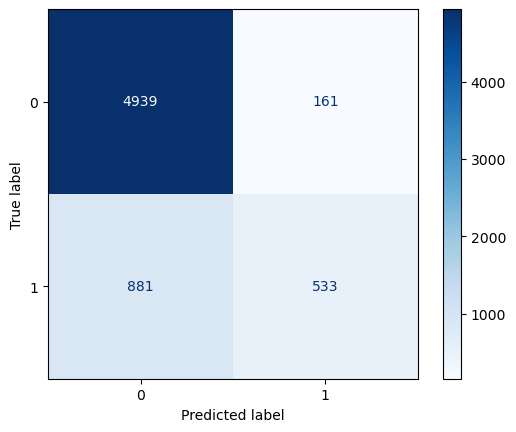

------------------ classification_report --------------------
              precision    recall  f1-score   support

           0       0.85      0.97      0.90      5100
           1       0.77      0.38      0.51      1414

    accuracy                           0.84      6514
   macro avg       0.81      0.67      0.71      6514
weighted avg       0.83      0.84      0.82      6514

------------------ More Specific classification_report --------------------
Accuracy:- 0.8400368437212159
Sensitivity:- 0.37694483734087697
Specificity:- 0.9684313725490196
F1-Score:- 0.5056925996204934
------------------ ROC --------------------


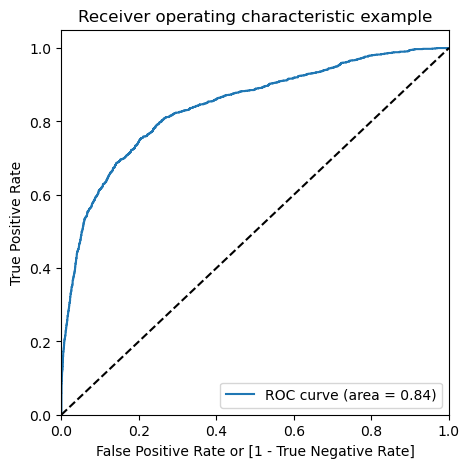

In [33]:
display_test_results("Logistic Regression", logistic_model)

**XGBoost**

In [34]:
# Importing XGBoost
from xgboost import XGBClassifier
params = {'learning_rate': 0.2,
          'max_depth': 2, 
          'n_estimators':200,
          'subsample':0.9,
         'objective':'binary:logistic'}

In [35]:
# fit model on training data
xgb_model = XGBClassifier(params = params)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

------------------ Confusion Matrix --------------------
[[4858  242]
 [ 378 1036]]


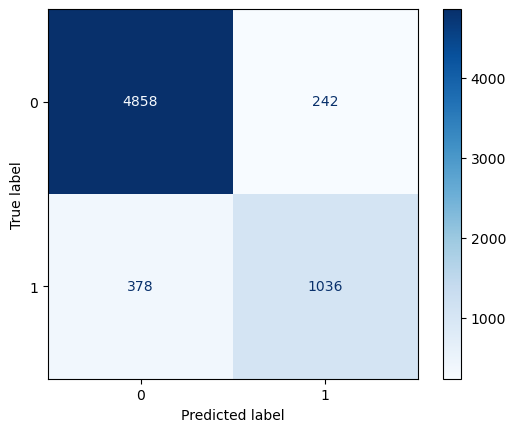

------------------ classification_report --------------------
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      5100
           1       0.81      0.73      0.77      1414

    accuracy                           0.90      6514
   macro avg       0.87      0.84      0.85      6514
weighted avg       0.90      0.90      0.90      6514

------------------ More Specific classification_report --------------------
Accuracy:- 0.9048203868590727
Sensitivity:- 0.7326732673267327
Specificity:- 0.9525490196078431
F1-Score:- 0.7696879643387816
------------------ ROC --------------------


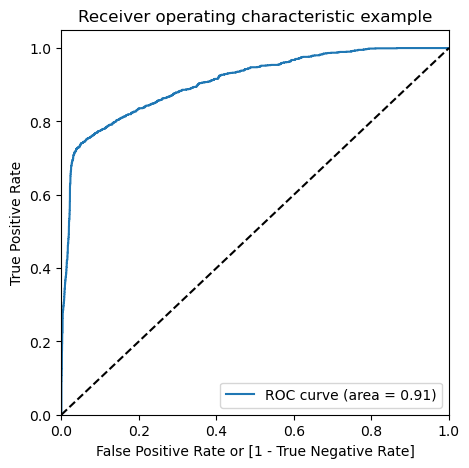

In [36]:
display_test_results("XG Boost", xgb_model)

**Decission Tree**

In [37]:
# Importing decision tree classifier
from sklearn.tree import DecisionTreeClassifier

In [38]:
# Model with optimal hyperparameters
decision_tree_model = DecisionTreeClassifier(criterion = "gini", 
                                  random_state = 100,
                                  max_depth=5, 
                                  min_samples_leaf=100,
                                  min_samples_split=100)

decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=100, min_samples_split=100,
                       random_state=100)

**Prediction Results Using Decision Tree**

------------------ Confusion Matrix --------------------
[[4925  175]
 [ 610  804]]


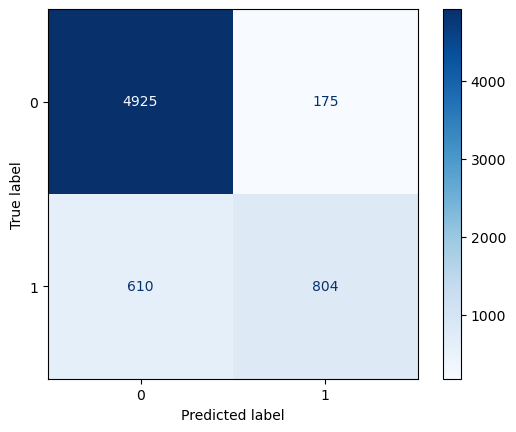

------------------ classification_report --------------------
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      5100
           1       0.82      0.57      0.67      1414

    accuracy                           0.88      6514
   macro avg       0.86      0.77      0.80      6514
weighted avg       0.87      0.88      0.87      6514

------------------ More Specific classification_report --------------------
Accuracy:- 0.8794903285231809
Sensitivity:- 0.5685997171145686
Specificity:- 0.9656862745098039
F1-Score:- 0.6719598829920602
------------------ ROC --------------------


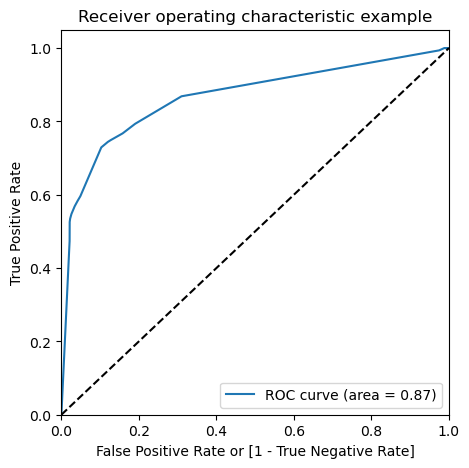

In [40]:
display_test_results("Decision Tree", decision_tree_model)

**Random Forest**

In [41]:
# Importing random forest classifier
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(bootstrap=True,
                             max_depth=5,
                             min_samples_leaf=50, 
                             min_samples_split=50,
                             max_features=10,
                             n_estimators=100)

In [42]:
# Fit the model
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, max_features=10, min_samples_leaf=50,
                       min_samples_split=50)

------------------ Confusion Matrix --------------------
[[4950  150]
 [ 470  944]]


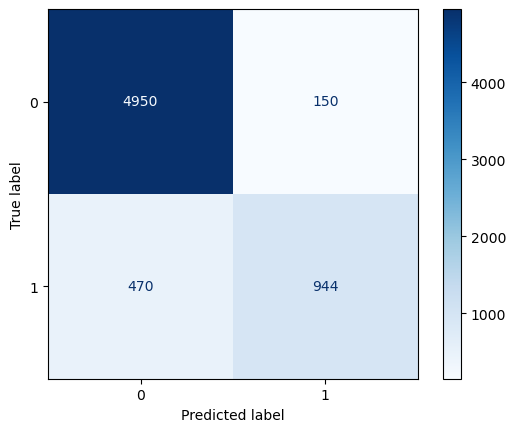

------------------ classification_report --------------------
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      5100
           1       0.86      0.67      0.75      1414

    accuracy                           0.90      6514
   macro avg       0.89      0.82      0.85      6514
weighted avg       0.90      0.90      0.90      6514

------------------ More Specific classification_report --------------------
Accuracy:- 0.9048203868590727
Sensitivity:- 0.6676096181046676
Specificity:- 0.9705882352941176
F1-Score:- 0.7527910685805422
------------------ ROC --------------------


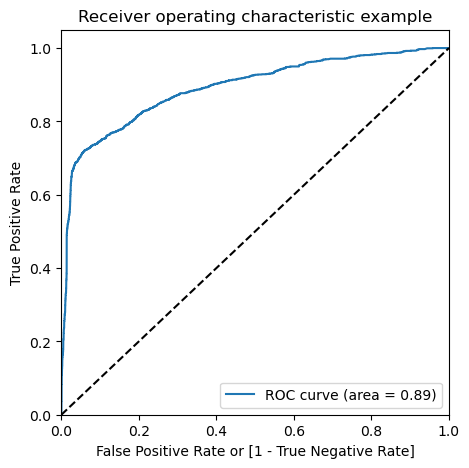

In [44]:
display_test_results("Random Forest", random_forest_model)

# 7 Summary

In [45]:
results.sort_values(by="ROC", ascending=False)

,Model Name,Accuracy,F1-score,ROC
1,XG Boost,0.904820,0.769688,0.907789
3,Random Forest,0.904820,0.752791,0.891523
2,Decision Tree,0.879490,0.671960,0.866631
0,Logistic Regression,0.840037,0.505693,0.842014


We can see that XG Boost Algorithm performing Better.